In [37]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# Afficher toutes les colonnes (aucune ne sera masquée avec des "...")
pd.set_option('display.max_columns', None)
# Empêcher le retour à la ligne (les colonnes s'afficheront sur une seule ligne avec un scroll horizontal)
pd.set_option('display.expand_frame_repr', False)
# Ne pas tronquer le contenu des cellules
pd.set_option('display.max_colwidth', None)

In [39]:
df = pd.read_csv("DatasetAfricaMalaria.csv", sep=",") 
print(df.head(20))
df.describe()

                Country Name  Year Country Code  Incidence of malaria (per 1,000 population at risk)  Malaria cases reported  Use of insecticide-treated bed nets (% of under-5 population)  Children with fever receiving antimalarial drugs (% of children under age 5 with fever)  Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)  People using safely managed drinking water services (% of population)  People using safely managed drinking water services, rural (% of rural population)  People using safely managed drinking water services, urban (% of urban population)  People using safely managed sanitation services (% of population)  People using safely managed sanitation services, rural (% of rural population)  People using safely managed sanitation services, urban  (% of urban population)  Rural population (% of total population)  Rural population growth (annual %)  Urban population (% of total population)  Urban population growth (annual %)  People using

,Year,"Incidence of malaria (per 1,000 population at risk)",Malaria cases reported,Use of insecticide-treated bed nets (% of under-5 population),Children with fever receiving antimalarial drugs (% of children under age 5 with fever),Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women),People using safely managed drinking water services (% of population),"People using safely managed drinking water services, rural (% of rural population)","People using safely managed drinking water services, urban (% of urban population)",People using safely managed sanitation services (% of population),"People using safely managed sanitation services, rural (% of rural population)","People using safely managed sanitation services, urban (% of urban population)",Rural population (% of total population),Rural population growth (annual %),Urban population (% of total population),Urban population growth (annual %),People using at least basic drinking water services (% of population),"People using at least basic drinking water services, rural (% of rural population)","People using at least basic drinking water services, urban (% of urban population)",People using at least basic sanitation services (% of population),"People using at least basic sanitation services, rural (% of rural population)","People using at least basic sanitation services, urban (% of urban population)",latitude,longitude
count,594.000000,550.000000,5.500000e+02,132.000000,122.000000,106.000000,99.000000,88.000000,176.000000,132.000000,110.000000,132.000000,588.000000,588.000000,588.000000,588.000000,588.000000,566.000000,566.000000,588.000000,566.000000,566.000000,594.000000,594.000000
mean,2012.000000,190.087491,1.068330e+06,42.530303,30.201639,15.013958,33.478990,12.470568,51.549545,28.768939,14.361727,32.174621,56.836650,1.389371,43.164116,3.523061,65.994915,51.449576,84.268498,39.469796,28.077208,48.088375,2.828796,17.342546
std,3.164943,163.054527,2.192802e+06,20.157059,18.903198,12.389166,26.678321,10.078371,24.157416,18.631510,7.088038,21.693458,18.086328,1.199693,18.086118,1.456244,17.283361,18.927868,9.307285,26.304934,24.046725,21.802128,15.678226,20.041257
min,2007.000000,0.000000,0.000000e+00,1.000000,0.500000,0.000000,5.770000,0.930000,11.200000,6.370000,2.300000,7.950000,11.020000,-3.450000,9.860000,-4.650000,28.960000,17.050000,52.010000,4.990000,1.890000,12.580000,-30.559482,-24.013197
25%,2009.000000,30.857500,2.211750e+03,26.675000,17.275000,5.763285,8.975000,4.185000,34.125000,16.532500,7.200000,18.262500,43.057500,0.410000,28.795000,2.512500,52.375000,37.075000,78.080000,18.197500,8.842500,30.775000,-6.369028,0.824782
50%,2012.000000,174.775000,1.130260e+05,42.900000,29.300000,11.500000,28.390000,10.675000,51.365000,25.410000,15.950000,22.755000,58.445000,1.675000,41.560000,3.730000,64.470000,50.435000,85.420000,32.555000,18.815000,44.695000,6.744051,18.611308
75%,2015.000000,347.637500,1.154808e+06,56.325000,42.625000,21.850000,43.890000,16.887500,70.747500,35.725000,20.315000,39.225000,71.205000,2.130000,56.945000,4.450000,79.165000,62.245000,90.082500,54.810000,38.082500,58.845000,12.862807,31.465866
max,2017.000000,585.540000,1.682113e+07,95.500000,76.900000,59.600000,92.660000,39.930000,89.540000,78.120000,25.540000,88.290000,90.140000,7.090000,88.980000,7.400000,99.870000,99.830000,99.920000,100.000000,95.180000,98.300000,33.886917,57.552152


In [40]:
df.info()
df.isna().sum()
df.duplicated()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1   Year                                                                                     594 non-null    int64  
 2   Country Code                                                                             594 non-null    object 
 3   Incidence of malaria (per 1,000 population at risk)                                      550 non-null    float64
 4   Malaria cases reported                                                                   550 non-null    float64
 5   Use of insecticide-treated bed nets (% of under-5 population)   

0      False
1      False
2      False
3      False
4      False
       ...  
589    False
590    False
591    False
592    False
593    False
Length: 594, dtype: bool

In [41]:

df_benin = df[df['Country Name'] == 'Benin'].copy()  

In [42]:
print(df_benin.columns.tolist())


['Country Name', 'Year', 'Country Code', 'Incidence of malaria (per 1,000 population at risk)', 'Malaria cases reported', 'Use of insecticide-treated bed nets (% of under-5 population)', 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)', 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'People using safely managed drinking water services (% of population)', 'People using safely managed drinking water services, rural (% of rural population)', 'People using safely managed drinking water services, urban (% of urban population)', 'People using safely managed sanitation services (% of population)', 'People using safely managed sanitation services, rural (% of rural population)', 'People using safely managed sanitation services, urban  (% of urban population)', 'Rural population (% of total population)', 'Rural population growth (annual %)', 'Urban population (% of total population)', 'Urban population growth (an

In [43]:
# 1. Nettoyage et Interpolation
df_benin_clean = df_benin.copy()
col_feature = 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)'
col_cases = 'Malaria cases reported'

df_benin_clean[col_feature] = df_benin_clean[col_feature].interpolate(method='linear').bfill().ffill()
df_benin_clean[col_cases] = df_benin_clean[col_cases].fillna(0)

# Variables globales (Toutes années confondues)
years_all = df_benin_clean['Year'].values
incidence_all = df_benin_clean['Incidence of malaria (per 1,000 population at risk)'].values  
itn_children_all = df_benin_clean[col_feature].values / 100 
cases_reported_all = df_benin_clean[col_cases].values.astype(int)

# Population at risk approximée (Globale)
pop_at_risk_approx = np.where(incidence_all > 0, cases_reported_all * 1000 / incidence_all, np.nan)
pop_at_risk_all = np.nan_to_num(pop_at_risk_approx, nan=1e6) 




In [44]:
# --- SÉPARATION TRAIN / VALIDATION / TEST (Chronologique) ---
mask_train = years_all <= 2013
mask_val = (years_all > 2013) & (years_all <= 2015)
mask_test = years_all >= 2016

# On applique le masque pour chaque ensemble
# Train
years_train, itn_train, cases_train, pop_train = years_all[mask_train], itn_children_all[mask_train], cases_reported_all[mask_train], pop_at_risk_all[mask_train]
# Val
years_val, itn_val, cases_val, pop_val = years_all[mask_val], itn_children_all[mask_val], cases_reported_all[mask_val], pop_at_risk_all[mask_val]
# Test
years_test, itn_test, cases_test, pop_test = years_all[mask_test], itn_children_all[mask_test], cases_reported_all[mask_test], pop_at_risk_all[mask_test]

In [45]:
# 2. Modèle PyMC avec pm.Data
with pm.Model() as malaria_benin_model:
    
    # pm.Data() permet de pouvoir échanger le jeu de Train par Val ou Test plus tard
    itn_data = pm.Data("itn_data", itn_train)
    # On centre les années en utilisant uniquement la moyenne du set d'entraînement !
    year_data = pm.Data("year_data", years_train - years_train.mean())
    pop_data = pm.Data("pop_data", pop_train)
    cases_obs_data = pm.Data("cases_obs_data", cases_train)
    
    # Priors
    intercept = pm.Normal("intercept", mu=np.log(incidence_all.mean() + 1e-6), sigma=1.5)
    beta_itn = pm.Normal("beta_itn", mu=-1.0, sigma=0.8) 
    beta_year = pm.Normal("beta_year", mu=0, sigma=0.2) 
    
    # Log du taux
    log_mu = intercept + beta_itn * itn_data + beta_year * year_data
    expected_cases = pm.Deterministic("expected_cases", pm.math.exp(log_mu) * (pop_data / 1000))
    
    # Likelihood 
    cases_obs = pm.Poisson("cases_obs", mu=expected_cases, observed=cases_obs_data, shape=itn_data.shape)
    
    # Apprentissage ! (On échantillonne sur l'entrainement)
    trace = pm.sample(draws=2000, tune=1500, chains=4, target_accept=0.95, random_seed=42)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_itn, beta_year]


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 839 seconds.


In [46]:
# --- 3. Diagnostics d'entraînement ---
print("\n=== Summary du Train ===")
print(az.summary(trace, var_names=["intercept", "beta_itn", "beta_year"]))

# --- 4. Validation et Test via sample_posterior_predictive ---
# On change les données contenues dans le modèle pour celles de Validation
with malaria_benin_model:
    pm.set_data({
        "itn_data": itn_val,
        # IMPORTANT : On continue de soustraire la moyenne de l'entraînement 
        "year_data": years_val - years_train.mean(), 
        "pop_data": pop_val,
        "cases_obs_data": cases_val
    })
    
    # On tire des prédictions à partir des poids déjà appris dans le trace
    val_ppc = pm.sample_posterior_predictive(trace, random_seed=42, return_inferencedata=True)
    
    # On calcule une métrique simple = Moyenne de l'erreur absolue (MAE) sur Validation
    val_pred_mean = val_ppc.posterior_predictive["cases_obs"].mean(dim=["chain", "draw"]).values
    mae_val = np.abs(cases_val - val_pred_mean).mean()
    print(f"\nErreur Moyenne Absolue (MAE) sur Validation : {mae_val:.2f} cas")

# Et la même chose pour le Test
with malaria_benin_model:
    pm.set_data({
        "itn_data": itn_test,
        "year_data": years_test - years_train.mean(),
        "pop_data": pop_test,
        "cases_obs_data": cases_test
    })

    test_ppc = pm.sample_posterior_predictive(trace, random_seed=42, return_inferencedata=True)
    
    test_pred_mean = test_ppc.posterior_predictive["cases_obs"].mean(dim=["chain", "draw"]).values
    mae_test = np.abs(cases_test - test_pred_mean).mean()
    print(f"Erreur Moyenne Absolue (MAE) sur Test       : {mae_test:.2f} cas")



=== Summary du Train ===
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
intercept  6.501  0.011   6.480    6.522      0.000    0.000    1457.0    1678.0    1.0
beta_itn  -1.304  0.030  -1.357   -1.247      0.001    0.001    1465.0    1756.0    1.0
beta_year -0.034  0.001  -0.035   -0.033      0.000    0.000    1688.0    1984.0    1.0


Sampling: [cases_obs]


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [cases_obs]


C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\
Python311\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')


Erreur Moyenne Absolue (MAE) sur Validation : 42550.04 cas


Erreur Moyenne Absolue (MAE) sur Test       : 114760.37 cas


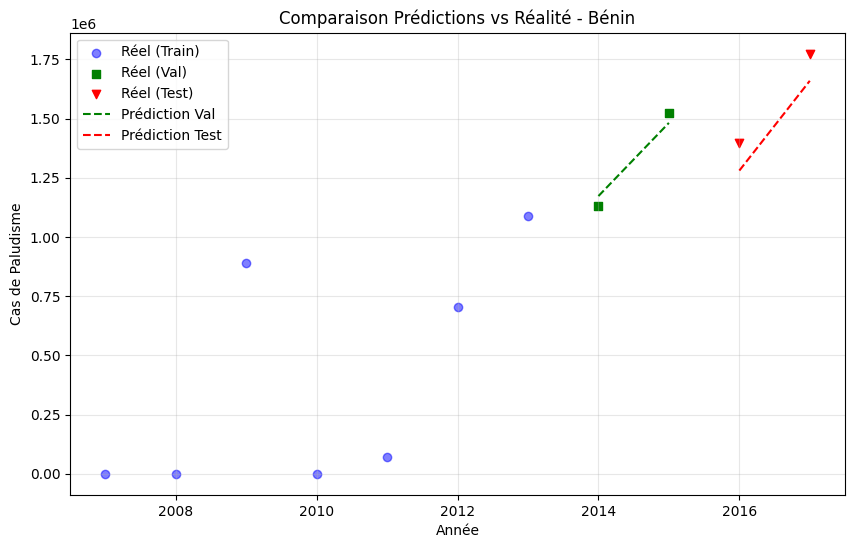

In [47]:
plt.figure(figsize=(10, 6))

# Données réelles
plt.scatter(years_train, cases_train, color='blue', label='Réel (Train)', alpha=0.5)
plt.scatter(years_val, cases_val, color='green', label='Réel (Val)', marker='s')
plt.scatter(years_test, cases_test, color='red', label='Réel (Test)', marker='v')

# Prédictions (moyennes)
# Note: On récupère les moyennes calculées précédemment
plt.plot(years_val, val_pred_mean, color='green', linestyle='--', label='Prédiction Val')
plt.plot(years_test, test_pred_mean, color='red', linestyle='--', label='Prédiction Test')

plt.title("Comparaison Prédictions vs Réalité - Bénin")
plt.xlabel("Année")
plt.ylabel("Cas de Paludisme")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
